In [67]:
import os.path

import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import seaborn as sns
from algbench import read_as_pandas
import re
import json

font = {'family': 'serif', 'size': 11}
matplotlib.rc('font', **font)

matplotlib.rcParams['axes.prop_cycle'] = matplotlib.cycler(color=[
    #"#6E2C00", combo
    "#27AE60",
    "#9B59B6",
    # "#CB4335",
    "#089099",
    #"#7C1D6F",
    "#045275",
    #"#ffffff",
])

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['figure.figsize'] = [9, 3.5]

In [68]:
algorithm_mapping = {
    "ip": "GUROBI (heuristic)",
    "cp-sat": "CP-SAT (heuristic)",
    "qtg": "QTG"
}
hue_order = [
    algorithm_mapping["ip"],
    algorithm_mapping["cp-sat"],
    algorithm_mapping["qtg"]
]

In [69]:
paths = ['classical_qtg_comparison/small', 'classical_qtg_comparison/large']

qtg_results = pd.concat([read_as_pandas(f'results/quantum_benchmark/{path}', lambda row: {
    'algorithm': 'qtg',
    'algorithm_human_readable': algorithm_mapping["qtg"],
    'size': row['parameters']['args']['instance']['size'],
    'elapsed_cycles': np.average([measure['cycle_count'] for measure in row['result']['measurements']]),
    'instance': row['parameters']['args']['instance']['name']
}) for path in paths], ignore_index=True)

ctg_results = pd.concat([read_as_pandas(f'results/ctg/{path}', lambda row: {
    'algorithm': 'ctg',
    'algorithm_human_readable': 'CTG',
    'elapsed_cycles': np.average(row['result']['elapsed_cycles']),
    'size': row['parameters']['args']['instance']['size'],
    'instance': row['parameters']['args']['instance']['name'],
    'qtg_estimate_cycles': np.average(
        [it * row['result']['qtg_cycles'] for it in row['result']['total_iterations']]),
}) for path in paths if os.path.isdir(f'results/ctg/{path}/results')], ignore_index=True)

with open("cached/optimal_solutions.json", "r") as f:
    optimal_solutions = json.load(f)

classical_results = read_as_pandas(f'results/heuristics', lambda row: {
    'algorithm': row['parameters']['args']['solver'],
    'algorithm_human_readable': algorithm_mapping[row['parameters']['args']['solver']],
    'size': row['parameters']['args']["kwargs"]['instance']['size'],
    'elapsed_cycles': row['result']['elapsed_cycles'] if 'elapsed_cycles' in row['result'] else -1,
    'instance': row['parameters']['args']["kwargs"]['instance']['name'],
    'objective_value': row['result']['objective_value'],
    'optimal': optimal_solutions[row['parameters']['args']["kwargs"]['instance']['name']]["objective"] ==  row['result']['objective_value']
})

combo_results = pd.concat([read_as_pandas(f'results/classical_benchmark/{path}', lambda row: {
    'algorithm': row['parameters']['args']['solver'],
    'algorithm_human_readable': algorithm_mapping[row['parameters']['args']['solver']],
    'size': row['parameters']['args']['instance']['size'],
    'elapsed_cycles': row['result']['elapsed_cycles'] if 'elapsed_cycles' in row['result'] else -1,
    'instance': row['parameters']['args']['instance']['name'],
    'objective_value': row['result']['objective_value'],
} if row['parameters']['args']['solver'] == "combo" else None) for path in paths], ignore_index=True)


classical_results['g'] = classical_results.apply(lambda row: int(re.match(r'.+\_g\_([0-9]+)\_.+', row['instance']).group(1)), axis=1)
qtg_results['g'] = qtg_results.apply(lambda row: int(re.match(r'.+\_g\_([0-9]+)\_.+', row['instance']).group(1)), axis=1)
ctg_results['g'] = ctg_results.apply(lambda row: int(re.match(r'.+\_g\_([0-9]+)\_.+', row['instance']).group(1)), axis=1)

def g_group(row):
    if row['g'] == 2:
        return "$g=2$"
    elif row['g'] > 2 and row['g'] <= 6:
        return "$3 \\leq g \\leq 6$"
    return "$7 \\leq g \\leq 10$"


ctg_results['g_group'] = ctg_results.apply(g_group, axis=1)
qtg_results['g_group'] = qtg_results.apply(g_group, axis=1)
classical_results['g_group'] = classical_results.apply(g_group, axis=1)

In [70]:
classical_results.groupby(['algorithm', "optimal"]).count()

algorithm_human_readable  size  elapsed_cycles  instance  \
algorithm optimal                                                             
cp-sat    False                         313   313             313       313   
          True                          335   335             335       335   
ip        False                         623   623             623       623   
          True                           25    25              25        25   

                   objective_value    g  g_group  
algorithm optimal                                 
cp-sat    False                313  313      313  
          True                 335  335      335  
ip        False                623  623      623  
          True                  25   25       25

['GUROBI (heuristic)', 'CP-SAT (heuristic)', 'QTG']
$g=2$
ip 25.0 %
cp-sat 47.22222222222222 %
$3 \leq g \leq 6$
ip 2.083333333333333 %
cp-sat 43.75 %
$7 \leq g \leq 10$
ip 0.3472222222222222 %
cp-sat 60.763888888888886 %


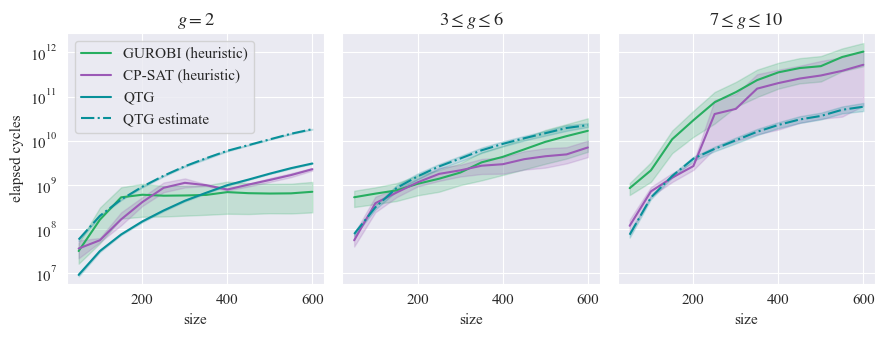

In [71]:
elapsed_cycles_comparison = pd.concat([
    classical_results,
    qtg_results
])


fig, axs = plt.subplots(figsize=(9, 3.5), ncols=3)

elapsed_cycles_hue_order = list(hue_order)


print(elapsed_cycles_hue_order)

for i, val in enumerate(['$g=2$', '$3 \\leq g \\leq 6$', '$7 \\leq g \\leq 10$']):

    current_comparison = elapsed_cycles_comparison[(elapsed_cycles_comparison['g_group'] == val)]
    print(val)
    for alg in ["ip", "cp-sat"]:
        alg_comp = current_comparison[current_comparison["algorithm"] == alg]
        print(alg, len(alg_comp[alg_comp["optimal"]]) / len(alg_comp) * 100, "%")

    sns.lineplot(current_comparison,
                 x='size', y='elapsed_cycles',
                 hue='algorithm_human_readable', hue_order=hue_order, ax=axs[i])

    sns.lineplot(ctg_results[(ctg_results['g_group'] == val)],
                 x='size', y='qtg_estimate_cycles', ax=axs[i], label="QTG estimate", linestyle='-.', color="C2")

    axs[i].set_title(val)

    axs[i].set_yscale('log')
    axs[i].set_ylabel("elapsed cycles")
    legend = axs[i].legend()
    texts = [algo.get_text() for algo in legend.get_texts()]
    lines = legend.get_lines()

    if i > 0: legend.remove()

min_y = min([ax.get_ylim()[0] for ax in axs])
max_y = max([ax.get_ylim()[1] for ax in axs])

for i, ax in enumerate(axs):
    ax.set_ylim(min_y, max_y)
    if i > 0:
        ax.set_yticklabels([])
        ax.set_ylabel("")


fig.tight_layout()
fig.savefig('out/11_elapsed_cycles_heuristics.pdf', bbox_inches='tight')
#_ = ax.legend(lines[0:1] + lines[4:], texts[0:1] + texts[4:], loc='upper left')

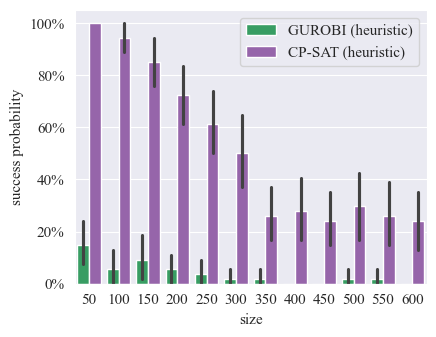

In [78]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(9, 3.5), ncols=3)


for i, val in enumerate(['$g=2$', '$3 \\leq g \\leq 6$', '$7 \\leq g \\leq 10$']):
    sns.barplot(classical_results, hue="algorithm_human_readable", dodge=True, x='size', y='optimal', ax=ax)

ax.set_ylabel("success probability")
ax.yaxis.set_major_formatter(ticker.PercentFormatter(1))
ax.legend().set_title(None)

fig.tight_layout()
plt.savefig(f"out/11_heuristic_success_prob.pdf", bbox_inches='tight')